In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from IPython.display import Audio
import os
from scipy.io.wavfile import write

In [3]:
# izvor podataka
base_path = '../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

data = []

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    flux = np.mean(np.diff(librosa.onset.onset_strength(y=y, sr=sr)))

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)

    features = [rms, zcr, centroid, bandwidth, rolloff, flux]
    features.extend(mfcc_mean)

    return features



for label in classes:
    folder = os.path.join(base_path, label)
    
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]
    
    for i, file in enumerate(files):
        path = os.path.join(folder, file)
        
        # debug
        if i % 10 == 0:
            print(f"   {label}: {i}/{len(files)} -> {file}")

        feats = extract_features(path)
        data.append(feats + [label])
        
print(f"\nGotovo! Ukupno uzoraka: {len(data)}")


columns = ['rms', 'zcr', 'centroid', 'bandwidth', 'rolloff', 'flux'] + [f'mfcc_{i}' for i in range(13)] + ['label']
df = pd.DataFrame(data, columns=columns)

df.head()

   BIC: 0/334 -> 583046e3-2023-10-15_15-42-8.0-Rathdowne4_TJN_NoV_L1_3Lanes_Idling_stereo.wav


/Users/dtx/Git/dyna-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   BIC: 10/334 -> 2023-08-02_13-13-46.0-Swanston5_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 20/334 -> 2023-08-01_16-6-13.5-Swanston1_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 30/334 -> 6df0d217-2023-08-04_10-25-39.0-Swanston6_TJN_NoV_L1_1Lane_Idling_mono.wav
   BIC: 40/334 -> 2023-10-15_15-17-37.6-Rathdowne3_FF_1V-Bic_L1_3Lanes_RL_stereo.wav
   BIC: 50/334 -> 683b1580-2023-10-15_15-29-12.0-Rathdowne3_FF_NoV_L1_3Lanes_Idling_stereo.wav
   BIC: 60/334 -> 2023-08-05_15-13-19.4-Swanston10_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 70/334 -> 250d3a1a-2023-08-04_12-7-24.0-Swanston7_TJN_NoV_L1_1Lane_Idling_mono.wav
   BIC: 80/334 -> 2023-10-15_15-47-20.5-Rathdowne3_FF_1V-Bic_L1_3Lanes_RL_stereo.wav
   BIC: 90/334 -> 1d8f36d8-2023-10-15_15-35-58.0-Rathdowne4_TJN_NoV_L1_3Lanes_Idling_stereo.wav
   BIC: 100/334 -> 2023-08-05_15-10-23.0-Swanston10_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 110/334 -> 2023-08-02_15-22-43.5-Swanston4_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 120/334 -> 2023-08-02_15-27-44

,rms,zcr,centroid,bandwidth,rolloff,flux,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,label
0,0.067933,0.019300,1795.349873,3061.477296,3516.123670,0.006684,-256.035339,179.060333,-20.816477,36.997948,-0.378067,23.683315,3.421184,7.036073,8.236278,10.495624,10.501118,0.638822,3.189926,BIC
1,0.041373,0.015038,1964.259902,3955.460255,3966.672207,0.006381,-357.677643,155.770950,14.896791,34.189884,8.492324,21.543243,12.588057,8.292775,6.722651,13.373618,8.834096,7.157313,-2.927626,BIC
2,0.024575,0.034442,2527.280451,4235.230198,5746.052194,0.008218,-326.819763,168.690674,3.152375,38.371349,-9.077016,13.049166,-1.313318,5.001542,1.534346,3.333797,-0.572079,7.276909,-7.196291,BIC
3,0.016139,0.037312,3461.693697,4962.301084,8513.048537,0.005787,-356.373749,141.109451,-0.588723,32.123829,-7.409817,21.454344,7.027060,11.915449,-0.374375,11.511097,-2.656335,15.962797,-3.561023,BIC
4,0.006969,0.116403,3891.333586,4358.967559,8935.671543,0.004906,-389.039551,132.802658,-37.067345,37.103573,-14.898435,14.134451,6.149874,2.330377,12.545837,-3.029364,5.129737,4.930906,-2.416079,BIC


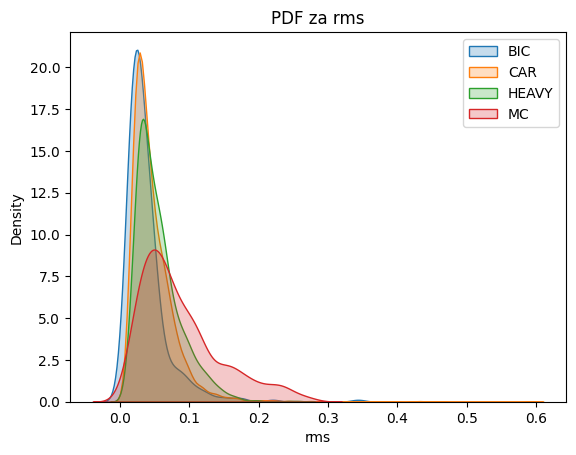

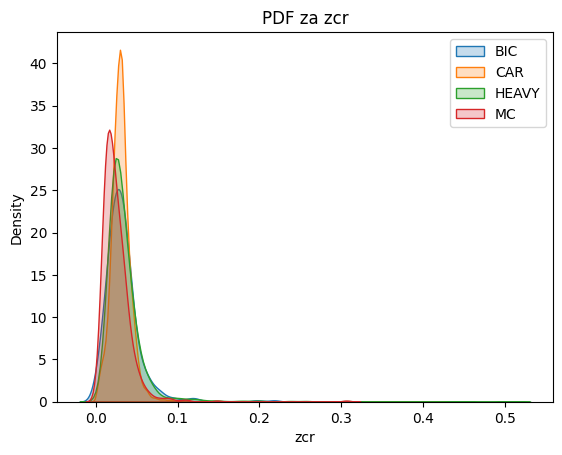

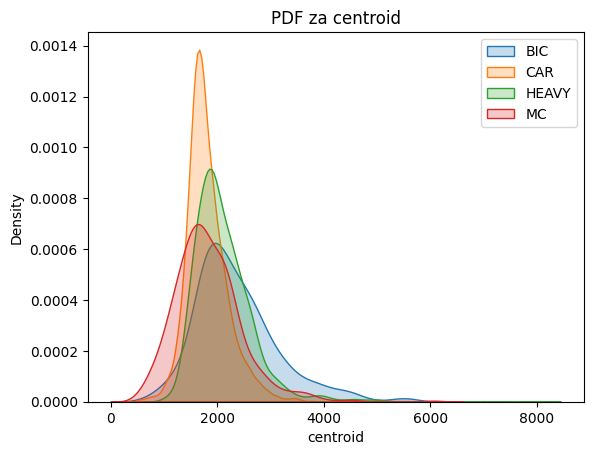

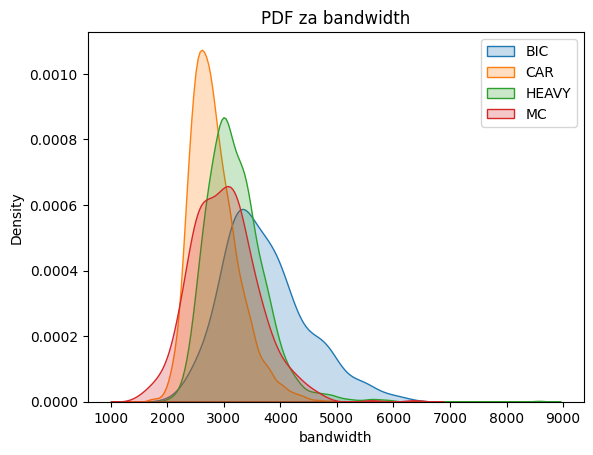

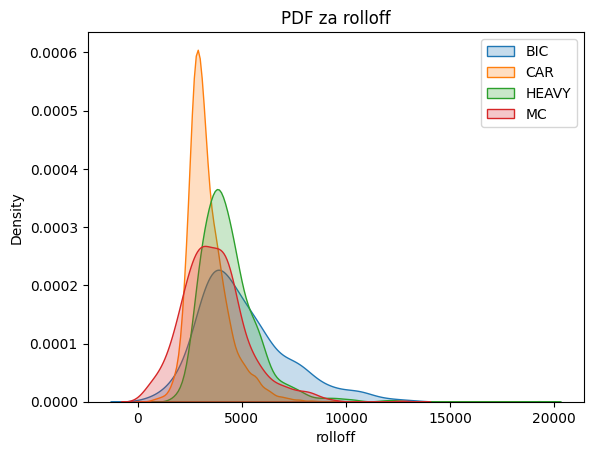

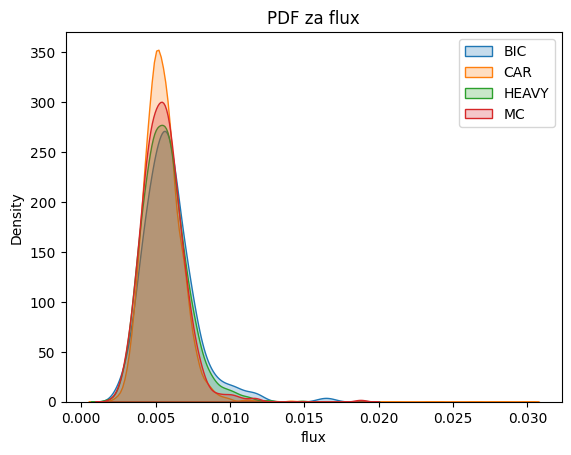

In [ ]:
# PDF (KDE) analiza za svaku značajku po klasama

features = ['rms', 'zcr', 'centroid', 'bandwidth', 'rolloff', 'flux']

for col in features:
    plt.figure()
    for label in df['label'].unique():
        subset = df[df['label'] == label]
        sns.kdeplot(subset[col], label=label, fill=True)
    plt.title(f'PDF za {col}')
    plt.legend()
    plt.show()

# Sto graf pokazuje? - kako su raspodijeljene vrijednosti znacajki prema klasama.
# sto je veci spike to je veci bias na toj klasi, sto nije pravilnija sinusoida, manja simetrija to skewness je veci
# Sto zelimo vidjeti? - zelimo da su raspodjele po klasama sto razlicitije, sto znaci da znacajka dobro razlikuje klase. 
# Sto ne zelimo vidjeti? - ne zelimo vidjeti puno preklapanja izmedju klasa, to znaci da znacajka ne razlikuje klase.

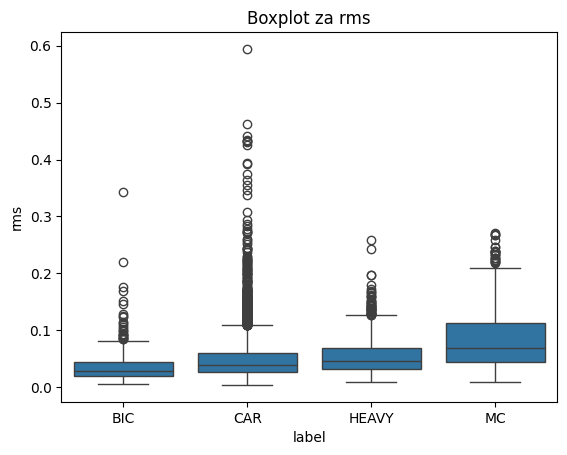

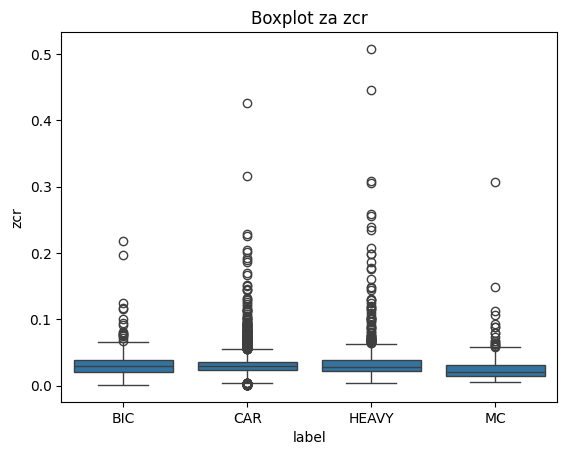

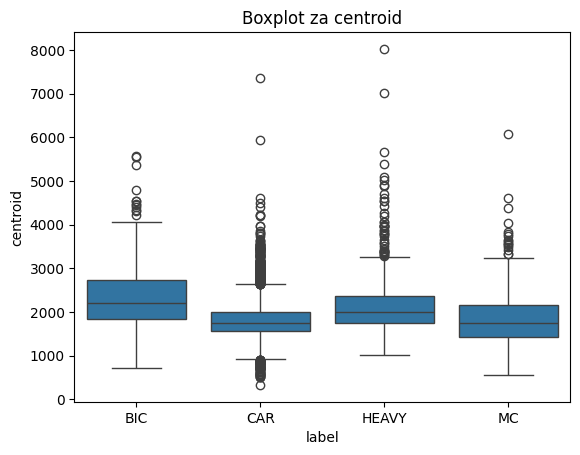

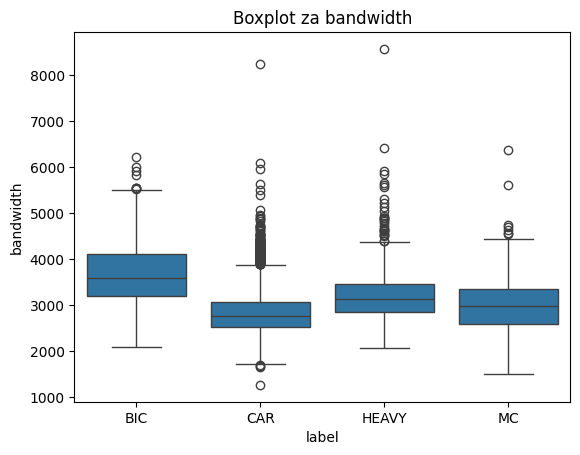

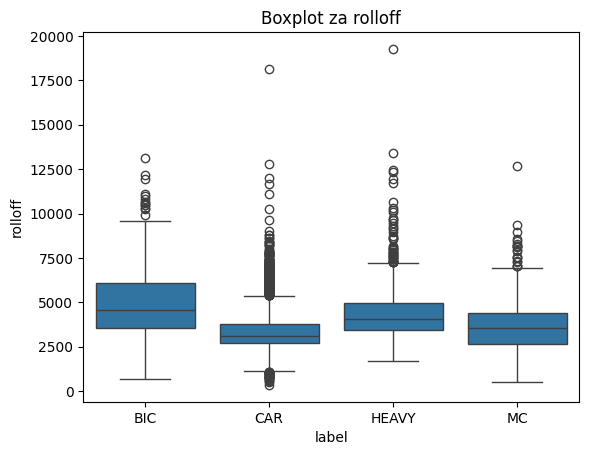

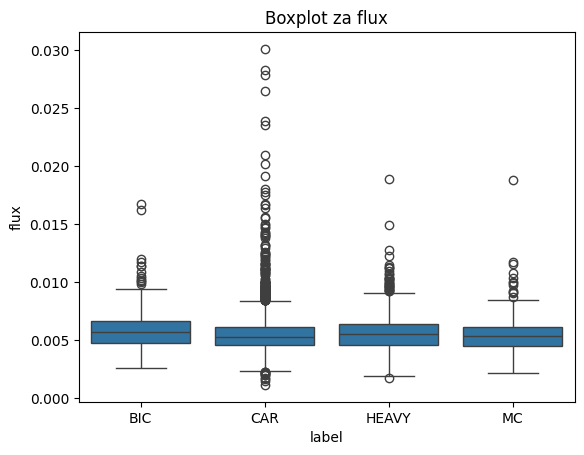

rms                                                              \
        count      mean       std       min       25%       50%       75%   
label                                                                       
BIC     334.0  0.037760  0.032807  0.005777  0.019185  0.028262  0.045103   
CAR    9348.0  0.047274  0.033914  0.004140  0.026407  0.038682  0.059343   
HEAVY  1190.0  0.055277  0.032229  0.009271  0.031655  0.047000  0.069573   
MC      519.0  0.086163  0.057183  0.009703  0.043691  0.069820  0.112035   

                    zcr            ...      rolloff                  flux  \
            max   count      mean  ...          75%           max   count   
label                              ...                                      
BIC    0.343367   334.0  0.032626  ...  6070.281333  13108.294548   334.0   
CAR    0.594258  9348.0  0.030741  ...  3781.042221  18128.906250  9348.0   
HEAVY  0.258044  1190.0  0.035442  ...  4952.979555  19267.744348  1190.0   
MC     0.270978   519.0  0.025046  ...  4419.527094  12698.138298   519.0   

                                                                             
           mean       std       min       25%       50%       75%       max  
label                                                                        
BIC    0.005895  0.001797  0.002637  0.004812  0.005721  0.006663  0.016701  
CAR    0.005479  0.001441  0.001162  0.004611  0.005330  0.006139  0.030091  
HEAVY  0.005634  0.001561  0.001752  0.004585  0.005505  0.006424  0.018926  
MC     0.005498  0.001461  0.002157  0.004549  0.005382  0.006187  0.018775  

[4 rows x 48 columns]

In [ ]:
# EDA - boxplotovi za svaku značajku po klasama

for col in features:
    plt.figure()
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f'Boxplot za {col}')
    plt.show()

df.groupby('label')[features].describe()

# Sto boxplot prikazuje? - medijan, raspon, outliere i distribuciju znacajki po klasama., treba plava kucica biti sto manja
# Sto zelimo vidjeti? - zelimo da su medijani i rasponi znacajki po klasama sto razlicitiji, sto znaci da znacajka dobro razlikuje klase.
# Sto ne zelimo vidjeti? - ne zelimo da su medijani i rasponi znacajki po klasama slicni, to znaci da znacajka ne razlikuje klase.

In [ ]:
# Bitnost značajki - F-test i mutual information

X = df.drop(columns=['label'])
y = df['label']

F, p = f_classif(X, y)
mi = mutual_info_classif(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'F_score': F,
    'p_value': p,
    'mutual_info': mi
}).sort_values(by='F_score', ascending=False)

importance_df

# Sto nam pokazuje tablica? - pokazuje nam koliko su znacajke bitne za razdvajanje klasa.
# r^2 statistika - za svaku znacajku posebno?
# Sto zelimo vidjeti? - zelimo da su F_score i mutual_info sto veci i p-value sto manji, sto znaci da znacajka dobro razlikuje klase.
# Sto ne zelimo vidjeti? - ne zelimo da su F_score i mutual_info mali i p-value velik, to znaci da znacajka ne razlikuje klase.

,feature,F_score,p_value,mutual_info
9,mfcc_3,877.402521,0.000000e+00,0.135520
3,bandwidth,584.130585,0.000000e+00,0.067357
7,mfcc_1,570.045926,0.000000e+00,0.080858
4,rolloff,490.177390,1.371471e-299,0.072306
11,mfcc_5,479.417316,2.231484e-293,0.070629
8,mfcc_2,421.308786,1.456500e-259,0.057159
10,mfcc_4,341.891613,1.358630e-212,0.049414
2,centroid,309.229559,5.125762e-193,0.043040
0,rms,224.305168,2.172798e-141,0.032717
6,mfcc_0,170.529213,3.811190e-108,0.042501


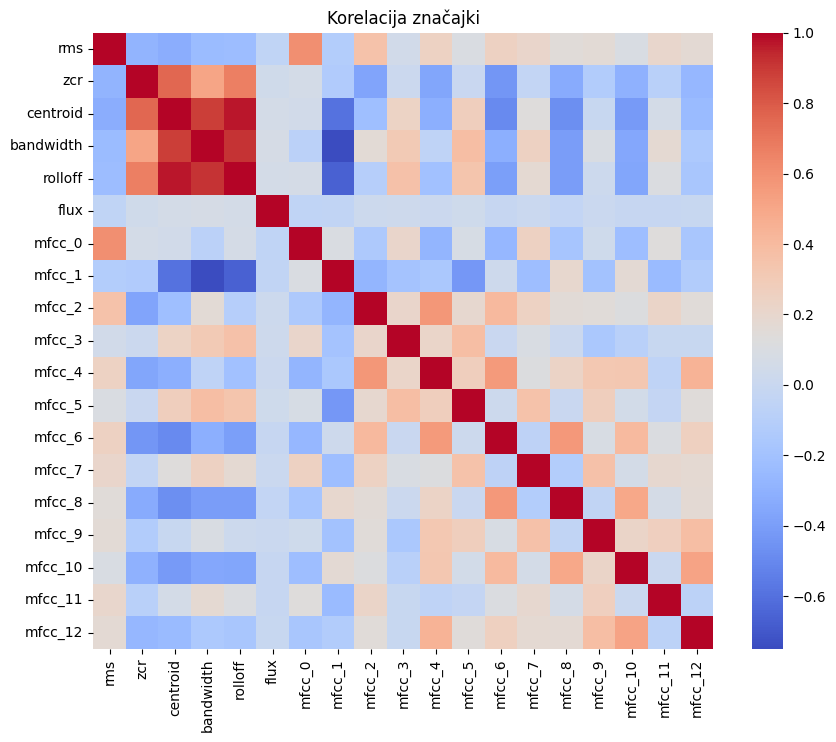

In [7]:
# Korelacija značajki

plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['label']).corr(), cmap='coolwarm')
plt.title('Korelacija značajki')
plt.show()

# Sto prikazuje graf? - prikazuje nam korelaciju izmedju znacajki.
# Sto zelimo vidjeti? - zelimo da su korelacije izmedju znacajki sto manje, sto znaci da znacajke nisu redundantne i da svaka znacajka doprinosi razdvajanju klasa.
# Sto ne zelimo vidjeti? - ne zelimo da su korelacije izmedju znacajki velike, to znaci da jednu od njih mozemo izbaciti jer ne doprinosi razdvajanju klasa, a samo usporava model i smanjuje točnost.


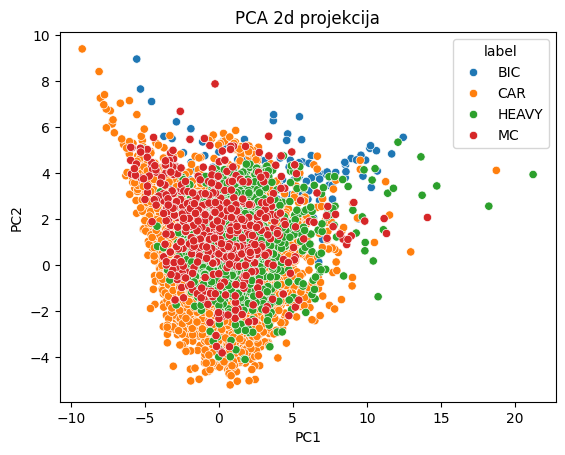

In [8]:
# PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame()
pca_df['PC1'] = X_pca[:,0]
pca_df['PC2'] = X_pca[:,1]
pca_df['label'] = y.values

plt.figure()
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label')
plt.title('PCA 2d projekcija')
plt.show()

# Sto nam graf prikazuje? - prikazuje nam kako su uzorci raspoređeni u prostoru 2D PCA (PCA - Principal Component Analysis)
# Sto zelimo vidjeti? - zelimo da su uzorci po klasama dobro razdvojeni u ovom prostoru.
# Sto ne zelimo vidjeti? - ne zelimo da se uzorci po klasama preklapaju



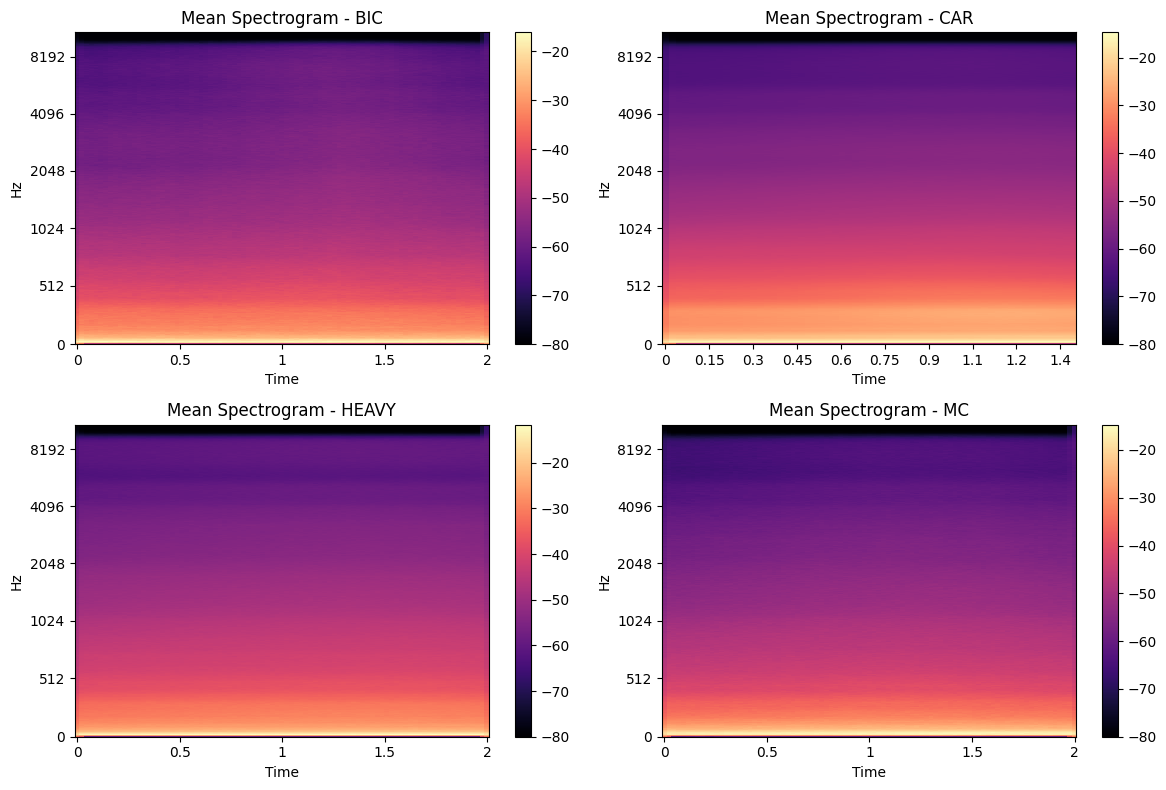

In [ ]:
def mean_spectrogram_per_class(base_path, classes):
    plt.figure(figsize=(12, 8))
    
    for i, label in enumerate(classes):
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        
        spectrograms = []
        
        for file in files:
            path = os.path.join(folder, file)
            y, sr = librosa.load(path, sr=22050)
            y = y[:sr*3]  # ograniči trajanje radi brzine
            
            S = np.abs(librosa.stft(y))
            S_db = librosa.amplitude_to_db(S, ref=np.max)
            
            spectrograms.append(S_db)
        
        # poravnavamo dimenzije spektrograma tako da svi imaju istu širinu (broj vremenskih okvira)
        min_shape = min([s.shape[1] for s in spectrograms])
        spectrograms = [s[:, :min_shape] for s in spectrograms]
        
        mean_spec = np.mean(spectrograms, axis=0)
        
        plt.subplot(2, 2, i+1)
        librosa.display.specshow(mean_spec, sr=sr, x_axis='time', y_axis='mel')
        plt.title(f"Mean Spectrogram - {label}")
        plt.colorbar()
    
    plt.tight_layout()
    plt.show()

mean_spectrogram_per_class(base_path, classes)

# ciscenje pa spektogrami za neki random zvuk
# train skup ce biti ociscen preko filtera

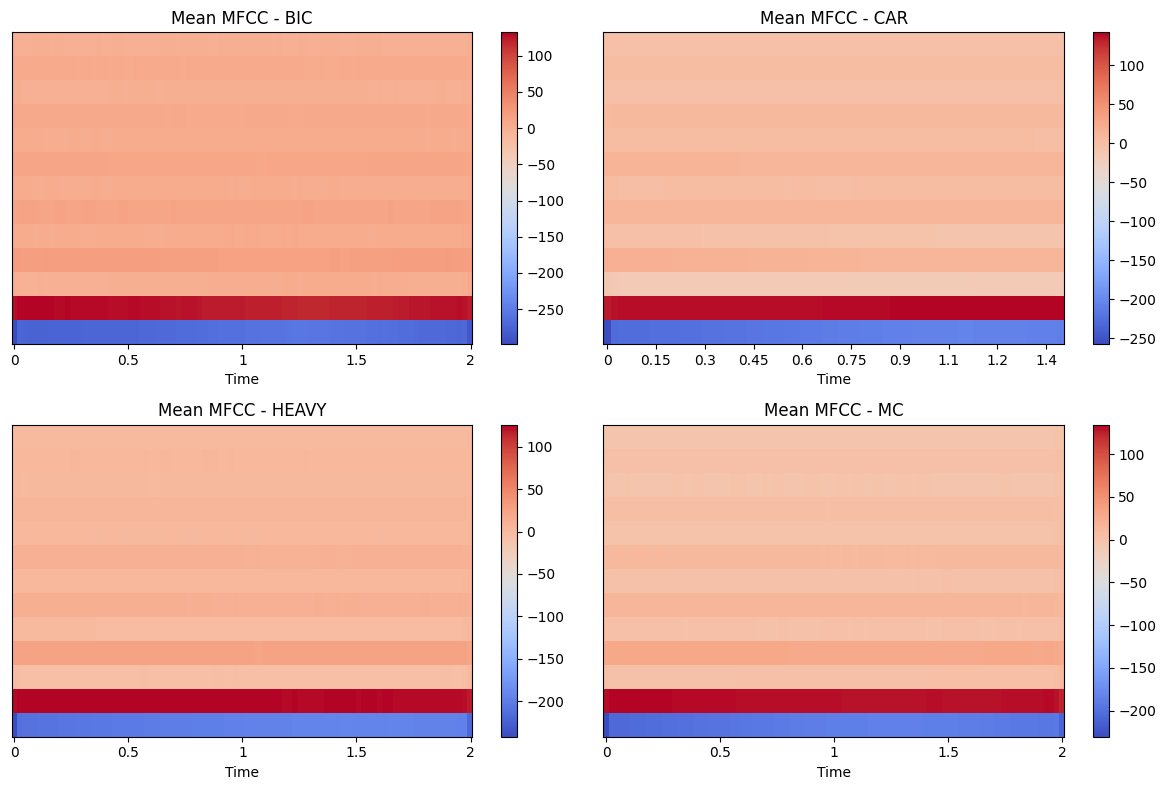

In [10]:
def mean_mfcc_per_class(base_path, classes):
    plt.figure(figsize=(12, 8))
    
    for i, label in enumerate(classes):
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]
        
        mfccs = []
        
        for file in files:
            path = os.path.join(folder, file)
            y, sr = librosa.load(path, sr=22050)
            y = y[:sr*3]
            
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfccs.append(mfcc)
        
        # poravnavamo dimenzije MFCC-a tako da svi imaju istu širinu (broj vremenskih okvira)
        min_shape = min([m.shape[1] for m in mfccs])
        mfccs = [m[:, :min_shape] for m in mfccs]
        
        mean_mfcc = np.mean(mfccs, axis=0)
        
        plt.subplot(2, 2, i+1)
        librosa.display.specshow(mean_mfcc, x_axis='time')
        plt.title(f"Mean MFCC - {label}")
        plt.colorbar()
    
    plt.tight_layout()
    plt.show()

mean_mfcc_per_class(base_path, classes)

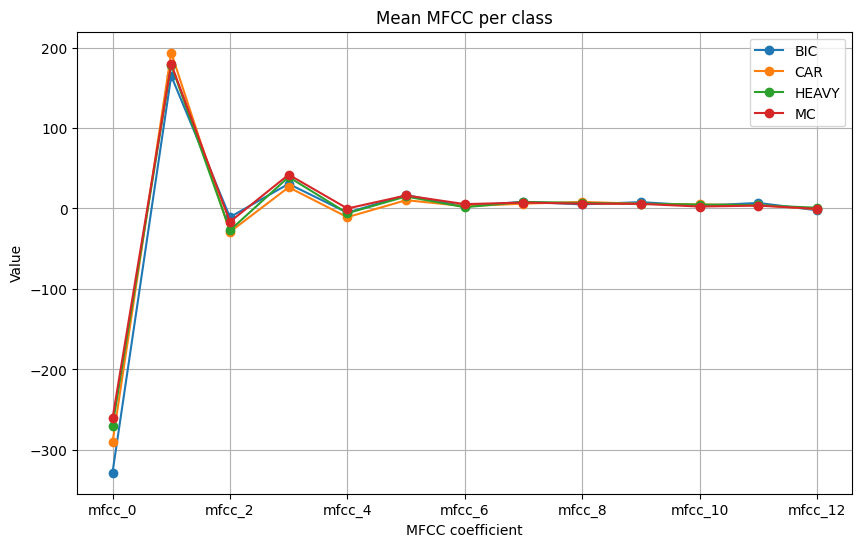

In [11]:
def plot_mean_mfcc_per_class(df):
    mfcc_cols = [col for col in df.columns if 'mfcc' in col]
    
    mean_mfcc = df.groupby('label')[mfcc_cols].mean()
    
    mean_mfcc.T.plot(figsize=(10,6), marker='o')
    plt.title("Mean MFCC per class")
    plt.xlabel("MFCC coefficient")
    plt.ylabel("Value")
    plt.grid()
    plt.legend()
    plt.show()

plot_mean_mfcc_per_class(df)

              precision    recall  f1-score   support

         BIC       0.80      0.29      0.42        83
         CAR       0.88      0.99      0.93      2337
       HEAVY       0.81      0.42      0.55       298
          MC       0.83      0.34      0.48       130

    accuracy                           0.88      2848
   macro avg       0.83      0.51      0.60      2848
weighted avg       0.87      0.88      0.86      2848



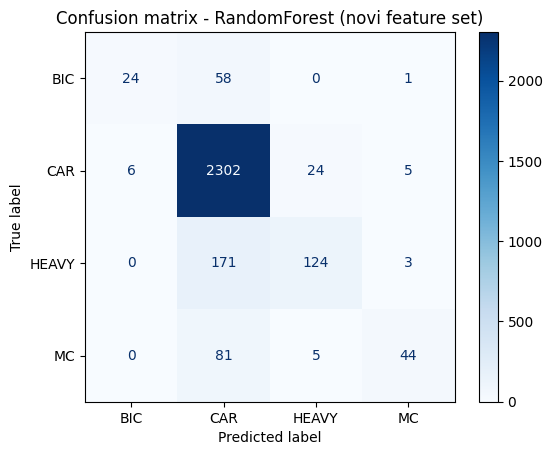

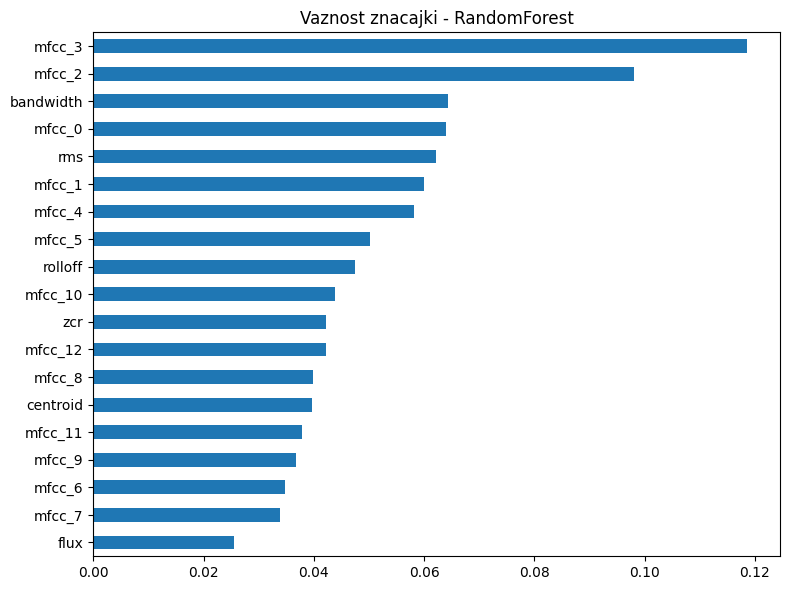

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - RandomForest (novi feature set)')
plt.show()

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Vaznost znacajki - RandomForest')
plt.tight_layout()
plt.show()